In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf
from sympy.vector import gradient
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

D:\Deep Learning 2 (Final)\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
df =pd.read_csv("Social_Network_Ads.csv")

In [4]:
X=df[['Age', 'EstimatedSalary']]
y=df[['Purchased']]

In [5]:
print(X.shape)
print(y.shape)


(400, 2)
(400, 1)


In [6]:
X
# print(y)

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [7]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X=scalar.fit_transform(X)

In [8]:
X.shape

(400, 2)

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [10]:
model=Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

D:\Deep Learning 2 (Final)\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
import time

model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start=time.time()
history=model.fit(X_train,y_train,epochs=500,batch_size=1,validation_split=0.2)
print(time.time()-start)

Epoch 1/500
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7305 - loss: 0.5878 - val_accuracy: 0.8750 - val_loss: 0.6026
Epoch 2/500
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8984 - loss: 0.5215 - val_accuracy: 0.9062 - val_loss: 0.5452
Epoch 3/500
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9062 - loss: 0.4513 - val_accuracy: 0.8906 - val_loss: 0.4565
Epoch 4/500
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9062 - loss: 0.3701 - val_accuracy: 0.8906 - val_loss: 0.3912
Epoch 5/500
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8984 - loss: 0.3228 - val_accuracy: 0.8906 - val_loss: 0.3529
Epoch 6/500
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9023 - loss: 0.3012 - val_accuracy: 0.8906 - val_loss: 0.3402
Epoch 7/500
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8984 - loss: 0.2924 - val_accuracy: 0.8906 - val_loss: 0.3373
Epoch 8/500
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8984 - loss: 0.2857 - val_accu

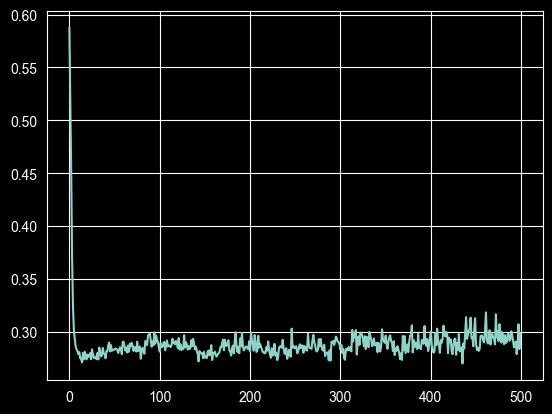

In [13]:
plt.plot(history.history['loss'])

In [14]:
import time

model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start=time.time()
history=model.fit(X_train,y_train,epochs=500,batch_size=400,validation_split=0.2)
print(time.time()-start)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9336 - loss: 0.2746 - val_accuracy: 0.8906 - val_loss: 0.4647
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9336 - loss: 0.2587 - val_accuracy: 0.8906 - val_loss: 0.4537
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9336 - loss: 0.2508 - val_accuracy: 0.8906 - val_loss: 0.4446
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9336 - loss: 0.2465 - val_accuracy: 0.8906 - val_loss: 0.4378
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9336 - loss: 0.2434 - val_accuracy: 0.8906 - val_loss: 0.4322
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9336 - loss: 0.2409 - val_accuracy: 0.8906 - val_loss: 0.4271
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9336 - loss: 0.2388 - val_accuracy: 0.8906 - val_loss: 0.4221
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9336 - loss: 0.2370 - val_accuracy: 0.8906 - val_loss

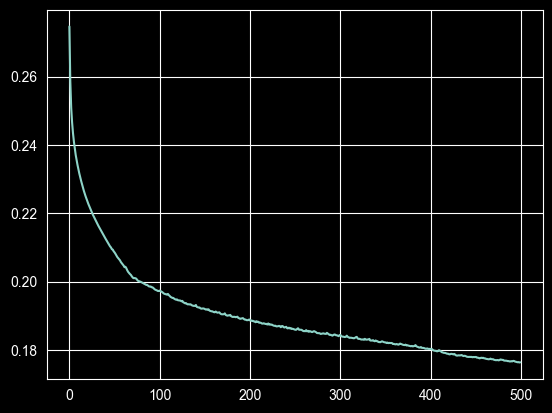

In [15]:
plt.plot(history.history['loss'])

In [16]:
import time

model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start=time.time()
history=model.fit(X_train,y_train,epochs=500,batch_size=80,validation_split=0.2)
print(time.time()-start)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9375 - loss: 0.1803 - val_accuracy: 0.8906 - val_loss: 0.2722
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9297 - loss: 0.1800 - val_accuracy: 0.8906 - val_loss: 0.2677
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9375 - loss: 0.1786 - val_accuracy: 0.8906 - val_loss: 0.2719
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9336 - loss: 0.1778 - val_accuracy: 0.8906 - val_loss: 0.2697
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9375 - loss: 0.1781 - val_accuracy: 0.8906 - val_loss: 0.2742
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9336 - loss: 0.1803 - val_accuracy: 0.8906 - val_loss: 0.2699
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9336 - loss: 0.1782 - val_accuracy: 0.8906 - val_loss: 0.2713
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9336 - loss: 0.1775 - val_accuracy: 0.8906 - val_loss:

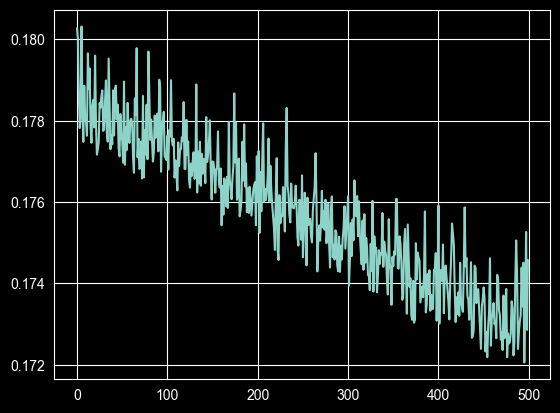

In [17]:
plt.plot(history.history['loss'])


In [55]:
from sklearn.datasets import make_moons

In [56]:
X,y=make_moons(n_samples=300,noise=0.01,random_state=42)

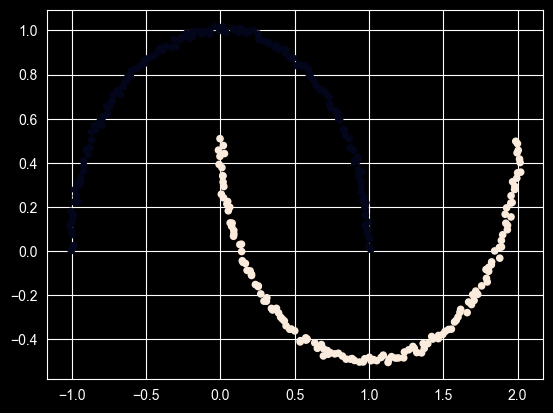

In [57]:
plt.scatter(X[:,0],X[:,1],c=y,s=20)
plt.show()

In [58]:
model=Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

D:\Deep Learning 2 (Final)\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [60]:
old_weight=model.get_weights()[0]

In [61]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [62]:
model.fit(X_train,y_train,epochs=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5167 - loss: 0.7343


In [63]:
new_weights=model.get_weights()[0]

In [64]:
gradient=(old_weight-new_weights)/ 0.001
percentage_change = abs(100*(old_weight - new_weights)/ old_weight)


In [65]:
gradient

array([[-0.00232458,  0.00721216, -0.00631809, -0.01531839, -0.00560097,
        -0.00864267, -0.00411272,  0.00718236, -0.01198053,  0.01479685],
       [ 0.00119209, -0.00338629,  0.00289083,  0.00703335,  0.00249594,
         0.00420213,  0.00217557, -0.00321865,  0.00548363, -0.00676513]],
      dtype=float32)

In [66]:
percentage_change

array([[0.00034431, 0.00263872, 0.00334955, 0.00881545, 0.0196163 ,
        0.00203186, 0.00060484, 0.00271113, 0.00428352, 0.01138154],
       [0.00019268, 0.00607873, 0.00276929, 0.00190491, 0.00263122,
        0.00114564, 0.00106047, 0.0006725 , 0.00188541, 0.00211302]],
      dtype=float32)